<a href="https://colab.research.google.com/github/granthi05/student-performance-analysis/blob/main/Student_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Student Performance Analysis

## 📌 Objective
To analyze student performance data using Python and identify key factors affecting final grades.

## 🛠 Tools Used
- Python
- Pandas
- Matplotlib
- Seaborn

## 📁 Dataset
Student Performance Dataset (student-mat.csv)

In [22]:
import pandas as pd

# Load raw file as single column
df = pd.read_csv("student-mat.csv")

# Split the column using semicolon
df = df.iloc[:, 0].str.split(';', expand=True)

# Load correct column names
columns = ["school","sex","age","address","famsize","Pstatus","Medu","Fedu",
           "Mjob","Fjob","reason","guardian","traveltime","studytime","failures",
           "schoolsup","famsup","paid","activities","nursery","higher","internet",
           "romantic","famrel","freetime","goout","Dalc","Walc","health",
           "absences","G1","G2","G3"]

df.columns = columns

df = df.replace('"', '', regex=True)

df.isnull().sum()

df = df.drop_duplicates()

df.shape

# Convert numeric columns
numeric_cols = ["age","Medu","Fedu","traveltime","studytime","failures",
                "famrel","freetime","goout","Dalc","Walc","health",
                "absences","G1","G2","G3"]

df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)

df.dtypes



df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## 📥 Data Loading

The dataset was loaded using the Pandas library. It contains student-related information such as demographic details, study habits, and academic performance.

The data was initially in a semi-structured format and required proper parsing to ensure correct column separation.

## 🔍 Data Exploration

Initial exploration was performed to understand the structure and characteristics of the dataset.

- Checked the shape of the dataset to determine the number of rows and columns.
- Examined column names to understand available features.
- Reviewed data types to distinguish between numerical and categorical variables.
- Generated summary statistics to identify trends and distributions.

This step helped in gaining a clear overview of the dataset before proceeding to cleaning and analysis.

## 🧹 Data Cleaning

Data cleaning was performed to ensure the dataset is accurate and ready for analysis.

- Fixed formatting issues caused by improper data separation.
- Removed unnecessary quotation marks from the dataset.
- Checked for missing values and confirmed data completeness.
- Removed duplicate records to maintain data integrity.
- Converted relevant columns to appropriate data types (numerical and categorical).

After cleaning, the dataset was structured, consistent, and suitable for further analysis.

In [28]:
#Analysis

print("Average Final Grade:", df["G3"].mean())

print("Students scoring above 15:", len(df[df["G3"] > 15]))

print("Student time vs Performance:", df["studytime"].corr(df["G3"]))

print("Gender Performance:", df.groupby("sex")["G3"].mean())

Average Final Grade: 10.415189873417722
Students scoring above 15: 40
Student time vs Performance: 0.09781968965319626
Gender Performance: sex
F     9.966346
M    10.914439
Name: G3, dtype: float64


## 📊 Analysis

### 1. Average Final Grade
The average final grade (G3) of students is **10.4**, indicating a moderate overall academic performance among students.

---

### 2. Students Scoring Above 15
A total of **40 students** scored above 15, showing that a smaller proportion of students achieved high academic excellence.

---

### 3. Study Time vs Performance
The correlation between study time and final grade is **0.09**, which indicates a **very weak positive relationship**.

This suggests that increasing study time alone does not significantly impact student performance, and other factors may play a more important role.

---

### 4. Gender-wise Performance
Average final grades by gender:
- **Male:** 10.91  
- **Female:** 9.96  

Male students perform slightly better on average. However, the difference is relatively small, indicating that gender is not a strong determining factor in academic performance.

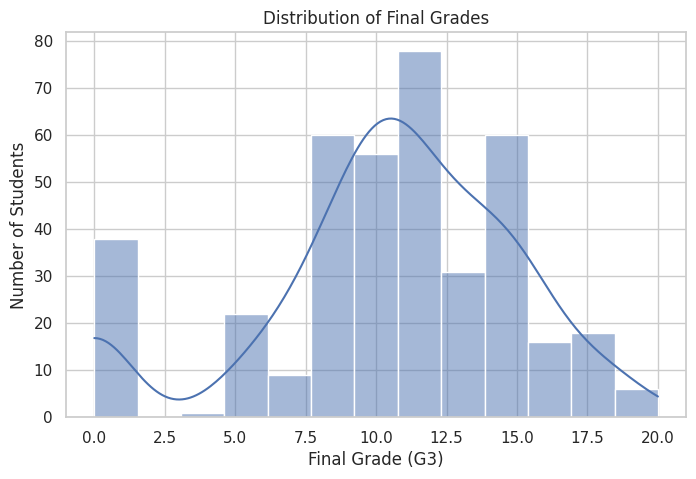

In [33]:
#Distribution of Final Grades

sns.set(style="whitegrid")
plt.figure(figsize=(8,5))
sns.histplot(df["G3"], kde=True)

plt.title("Distribution of Final Grades")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")

plt.show()

### 📊 Distribution of Final Grades

The histogram shows that most students score in the mid-range, with fewer students achieving very high or very low grades.

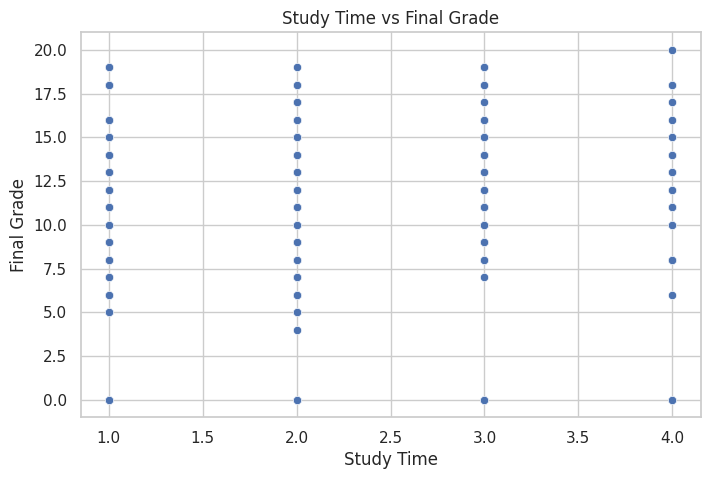

In [34]:
#Study Time vs Performance

sns.set(style="whitegrid")
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["studytime"], y=df["G3"])

plt.title("Study Time vs Final Grade")
plt.xlabel("Study Time")
plt.ylabel("Final Grade")

plt.show()

### 📊 Study Time vs Performance

The scatter plot shows a weak relationship between study time and final grades, supporting the earlier correlation result.

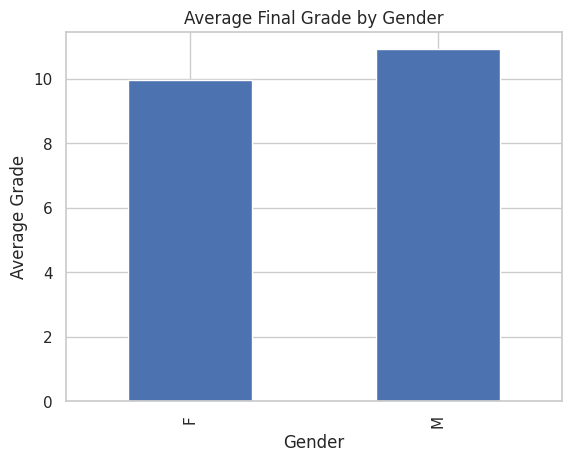

In [32]:
#Gender-wise Performance

sns.set(style="whitegrid")
df.groupby("sex")["G3"].mean().plot(kind="bar")

plt.title("Average Final Grade by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Grade")

plt.show()

### 📊 Gender-wise Performance

The bar chart shows that male students have a slightly higher average grade than female students, though the difference is small.

## 📌 Conclusion

This project analyzed student performance data to identify key factors affecting academic outcomes.

Key findings include:

- The average student performance is moderate, with a mean final grade of 10.4.
- Only a limited number of students scored above 15, indicating that high academic achievement is less common.
- Study time shows a very weak correlation with final grades, suggesting that other factors influence performance more significantly.
- Male students performed slightly better on average than female students, although the difference is minimal.

Overall, the analysis highlights that student performance is influenced by multiple factors beyond just study time. This project demonstrates the importance of data-driven insights in understanding real-world problems.